# EDA: Анализ цен объектов недвижимости
**Источник данных:** `data/listings.parquet`  
**Цель:** предсказание цены объекта недвижимости

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_parquet('../data/listings.parquet')
print(f'Строк: {len(df):,}  |  Колонок: {df.shape[1]}')
df.head()

Строк: 49,699  |  Колонок: 19


,id,price,total_area,rooms_code,floor,floors,distance,remont_code,hometype_code,deal_type_code,category,property_kind,region_id,bucket,new_building,lat,lon,first_seen_at,disappeared_at
0,42,5500000.0,110.0,10,2,2,<NA>,1,5,1,owner,sale,47,suburban,<NA>,55.474144,39.014587,2026-05-06 14:51:57.870163+00:00,None
1,44,8700000.0,28.0,1,3,5,16,3,2,1,owner,sale,47,urban,<NA>,55.788864,37.297962,2026-05-06 14:51:58.825417+00:00,None
2,46,18000000.0,63.0,3,1,9,6,3,2,1,owner,sale,46,urban,<NA>,55.812252,37.804718,2026-05-06 14:51:59.736234+00:00,None
3,47,5600000.0,48.0,10,1,1,<NA>,4,5,1,owner,sale,47,suburban,<NA>,55.370186,38.391041,2026-05-06 14:52:00.201410+00:00,None
4,48,1500000.0,10.0,11,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,owner,sale,47,suburban,<NA>,56.108383,36.613575,2026-05-06 14:52:00.669846+00:00,None


## 1. Распределения числовых фич

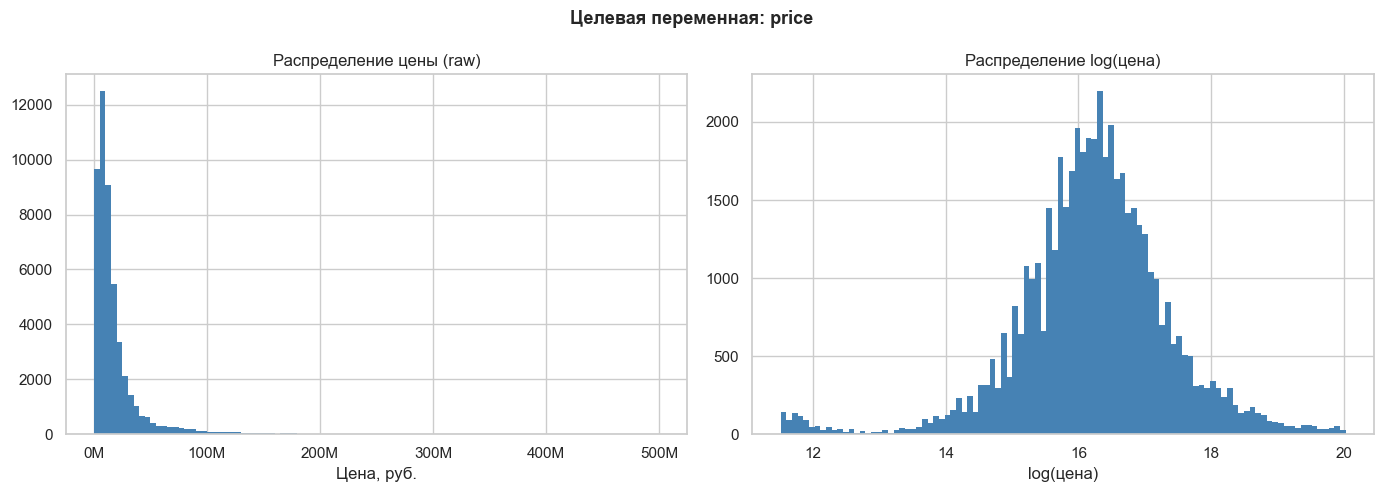

count         49,699
mean      21,343,112
std       38,542,882
min          100,000
25%        6,200,000
50%       11,500,000
75%       21,000,000
max      500,000,000
Name: price, dtype: str


In [3]:
# --- Распределение цены ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'].dropna(), bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Распределение цены (raw)')
axes[0].set_xlabel('Цена, руб.')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

axes[1].hist(np.log1p(df['price'].dropna()), bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Распределение log(цена)')
axes[1].set_xlabel('log(цена)')

plt.suptitle('Целевая переменная: price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df['price'].describe().apply(lambda x: f'{x:,.0f}'))

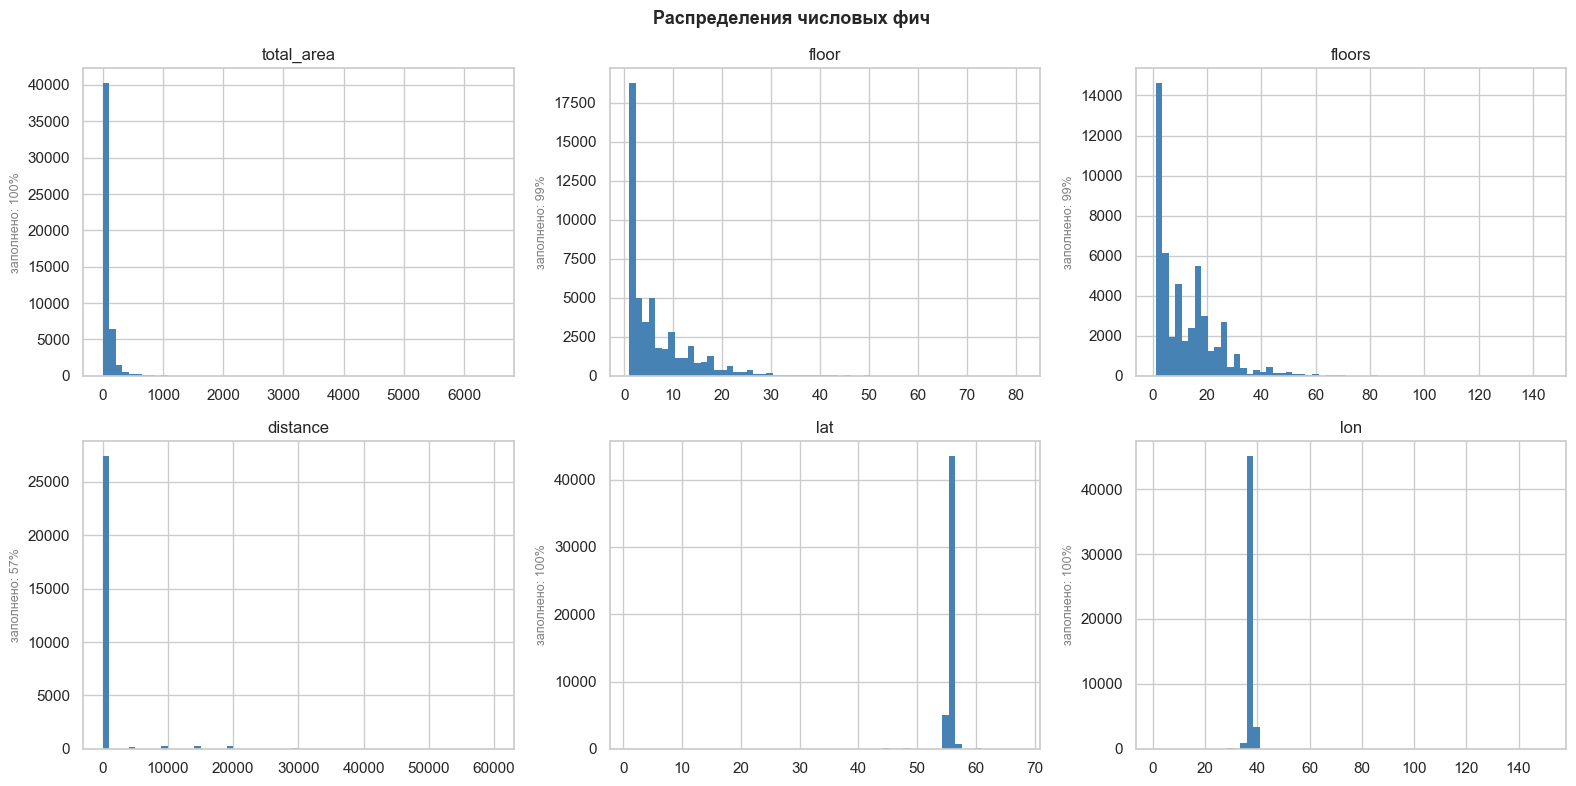

In [4]:
# --- Числовые фичи ---
num_cols = ['total_area', 'floor', 'floors', 'distance', 'lat', 'lon']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    data = df[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='none')
    ax.set_title(col)
    fill_pct = df[col].notna().mean() * 100
    ax.set_ylabel(f'заполнено: {fill_pct:.0f}%', fontsize=9, color='gray')

plt.suptitle('Распределения числовых фич', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Корреляции с целевой переменной

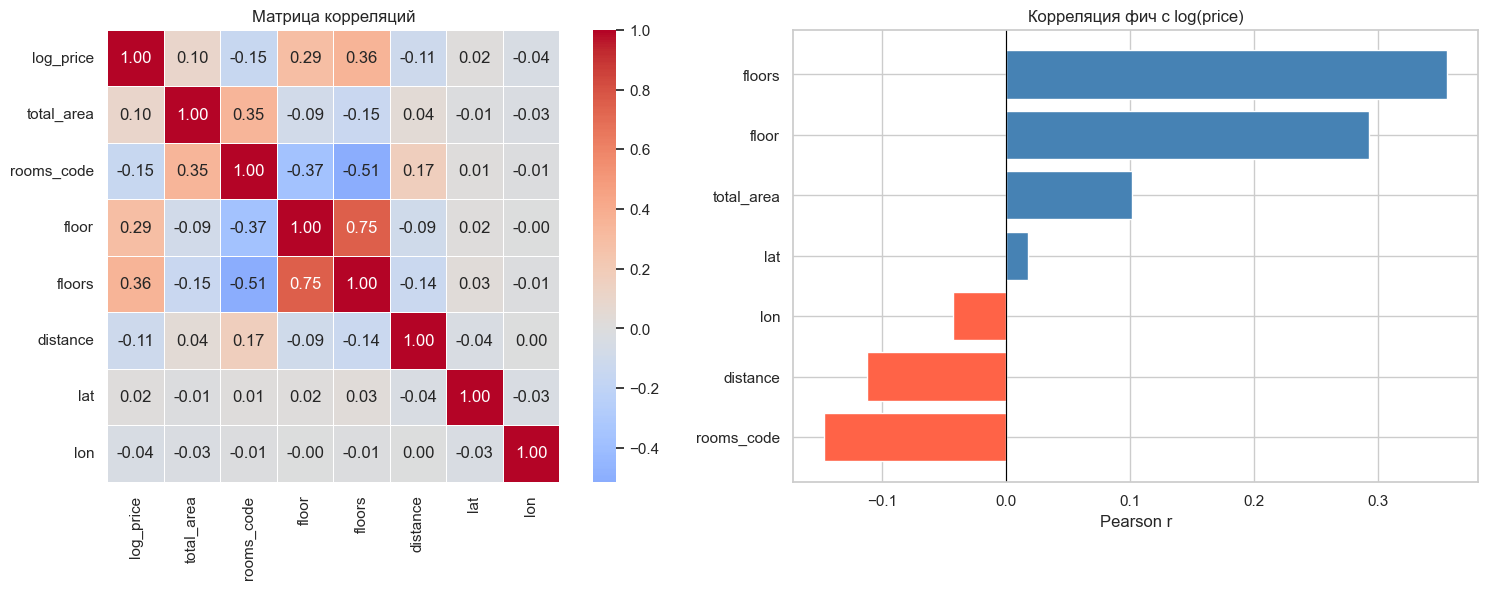

In [5]:
# --- Корреляция числовых фич с log(price) ---
df['log_price'] = np.log1p(df['price'])

corr_cols = ['log_price', 'total_area', 'rooms_code', 'floor', 'floors', 'distance', 'lat', 'lon']
corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Матрица корреляций')

corr_price = corr['log_price'].drop('log_price').sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_price]
axes[1].barh(corr_price.index, corr_price.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Корреляция фич с log(price)')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

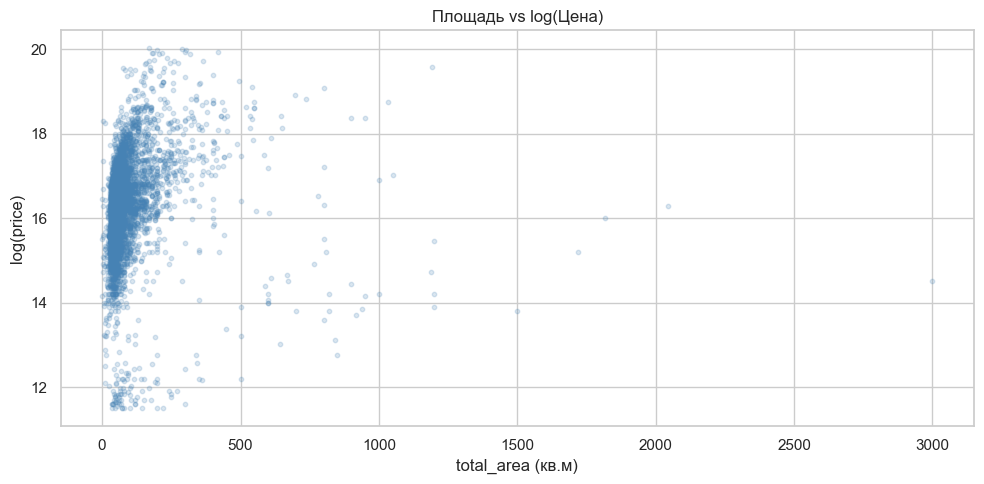

In [6]:
# --- Scatter: total_area vs price ---
sample = df[['total_area', 'log_price']].dropna().sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['total_area'], sample['log_price'], alpha=0.2, s=10, color='steelblue')
plt.xlabel('total_area (кв.м)')
plt.ylabel('log(price)')
plt.title('Площадь vs log(Цена)')
plt.tight_layout()
plt.show()

## 3. Категориальные фичи

C:\Users\Caesar\AppData\Local\Temp\ipykernel_10256\1667208380.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='log_price', order=order, ax=ax,
C:\Users\Caesar\AppData\Local\Temp\ipykernel_10256\1667208380.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='log_price', order=order, ax=ax,


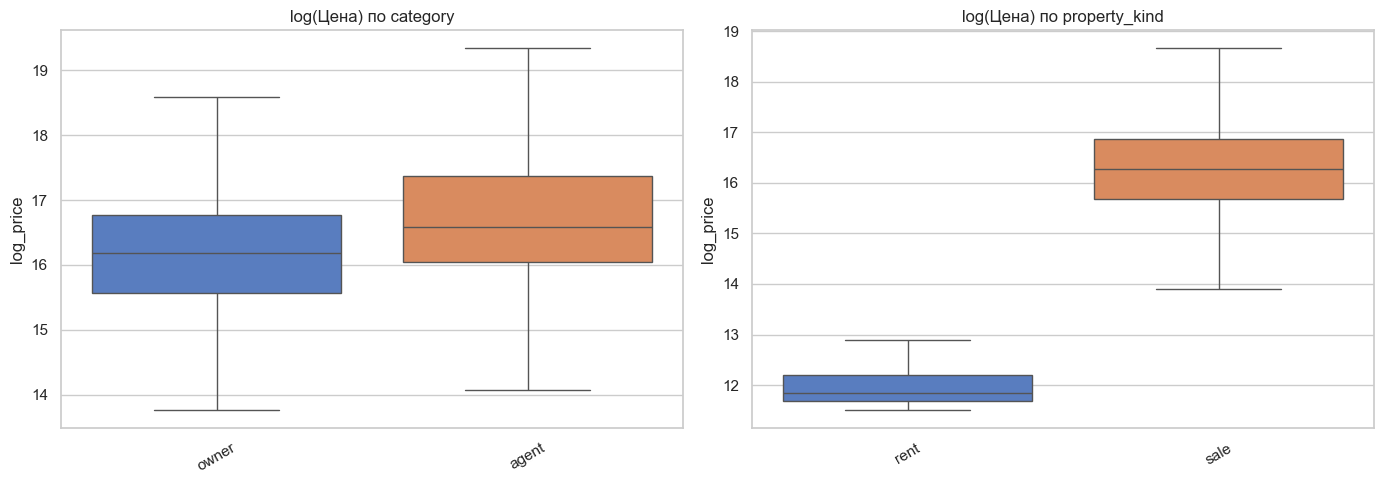

In [7]:
# --- Цена по category и property_kind ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['category', 'property_kind']):
    order = df.groupby(col)['log_price'].median().sort_values().index
    sns.boxplot(data=df, x=col, y='log_price', order=order, ax=ax,
                showfliers=False, palette='muted')
    ax.set_title(f'log(Цена) по {col}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

C:\Users\Caesar\AppData\Local\Temp\ipykernel_10256\4018640344.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bucket', y='log_price', order=bucket_order,


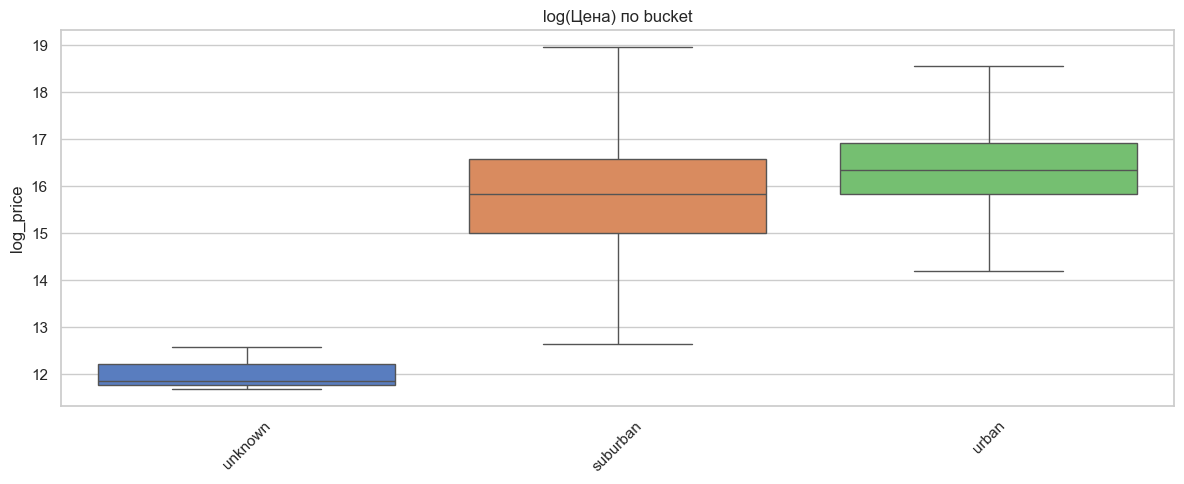

In [8]:
# --- Цена по bucket ---
bucket_order = df.groupby('bucket')['log_price'].median().sort_values().index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='bucket', y='log_price', order=bucket_order,
            showfliers=False, palette='muted')
plt.title('log(Цена) по bucket')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

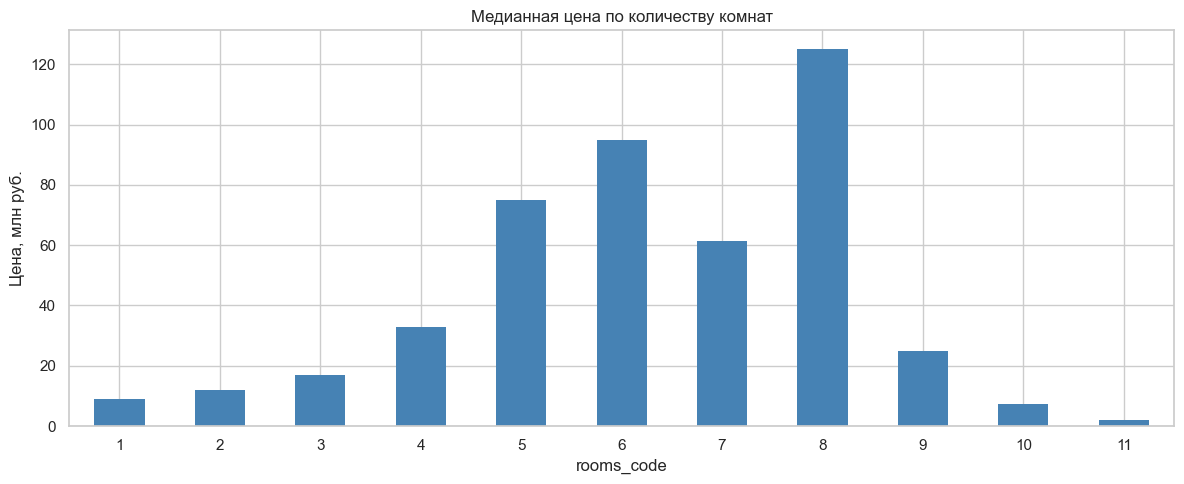

In [9]:
# --- Медианная цена по количеству комнат ---
rooms_median = df.groupby('rooms_code')['price'].median() / 1e6

plt.figure(figsize=(12, 5))
rooms_median.plot(kind='bar', color='steelblue', edgecolor='none')
plt.title('Медианная цена по количеству комнат')
plt.xlabel('rooms_code')
plt.ylabel('Цена, млн руб.')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

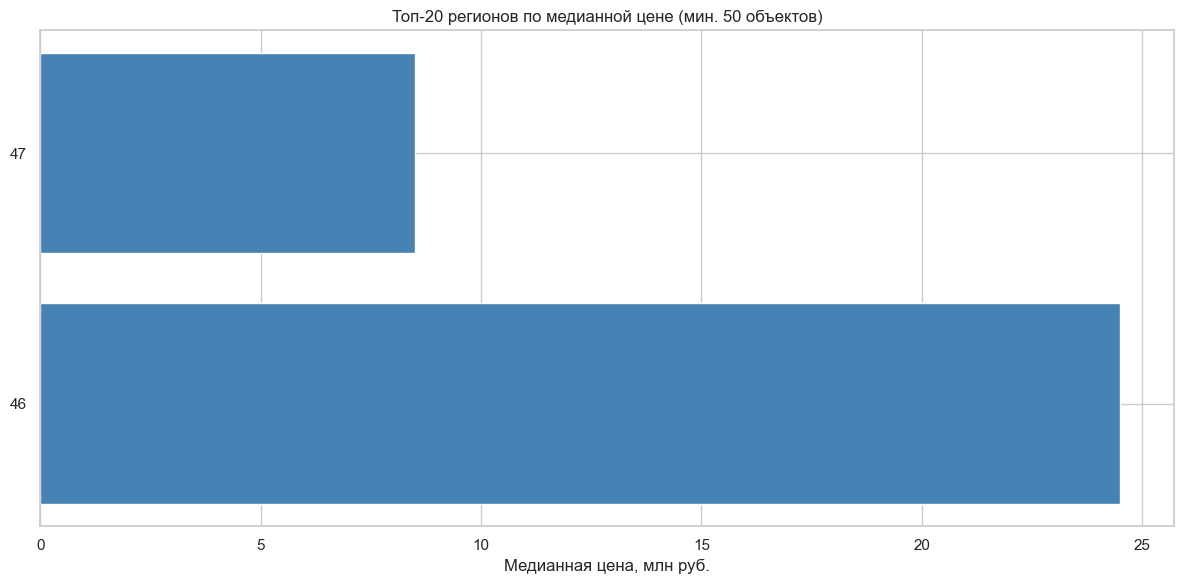

In [10]:
# --- Топ-20 регионов по медианной цене ---
top_regions = df.groupby('region_id')['price'].agg(['median', 'count'])
top_regions = top_regions[top_regions['count'] >= 50].nlargest(20, 'median')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_regions.index.astype(str), top_regions['median'] / 1e6, color='steelblue')
ax.set_xlabel('Медианная цена, млн руб.')
ax.set_title('Топ-20 регионов по медианной цене (мин. 50 объектов)')
plt.tight_layout()
plt.show()

## 4. Геовизуализация

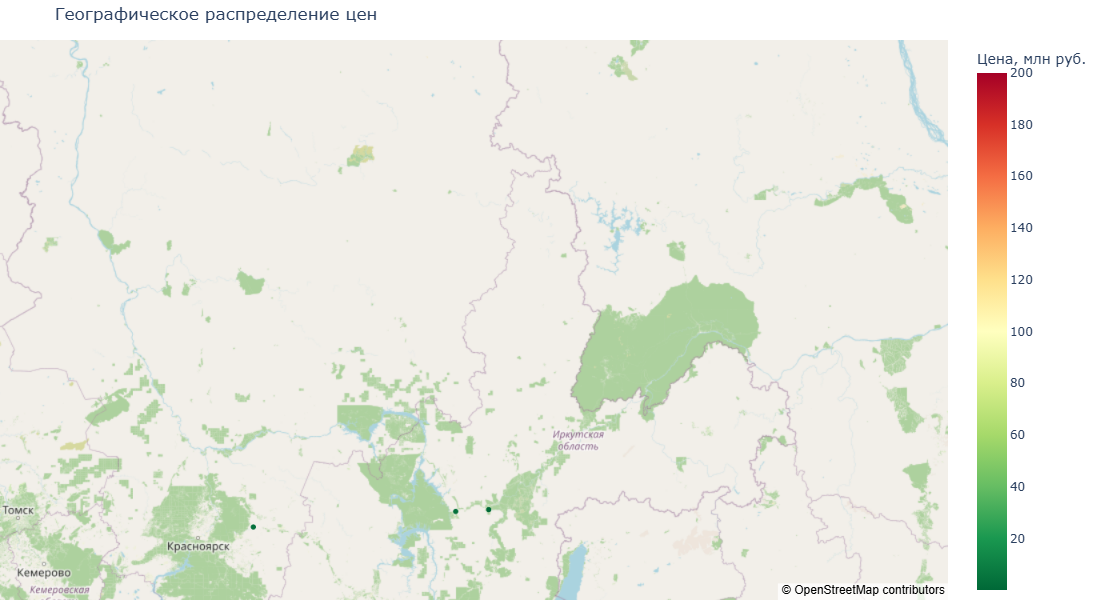

In [11]:
# --- Интерактивная карта цен на карте России ---
geo = df[['lat', 'lon', 'price']].dropna()
p1, p99 = geo['price'].quantile([0.01, 0.99])
geo = geo[(geo['price'] >= p1) & (geo['price'] <= p99)]
sample_geo = geo.sample(min(10000, len(geo)), random_state=42).copy()
sample_geo['price_m'] = (sample_geo['price'] / 1e6).round(1)

fig = px.scatter_map(
    sample_geo,
    lat='lat',
    lon='lon',
    color='price_m',
    color_continuous_scale='RdYlGn_r',
    size_max=6,
    zoom=4,
    center={'lat': 61, 'lon': 105},
    map_style='open-street-map',
    labels={'price_m': 'Цена, млн руб.'},
    title='Географическое распределение цен',
    hover_data={'price_m': True, 'lat': False, 'lon': False}
)
fig.update_layout(height=600, margin={'r': 0, 't': 40, 'l': 0, 'b': 0})
fig.show()

## 5. Анализ пропусков

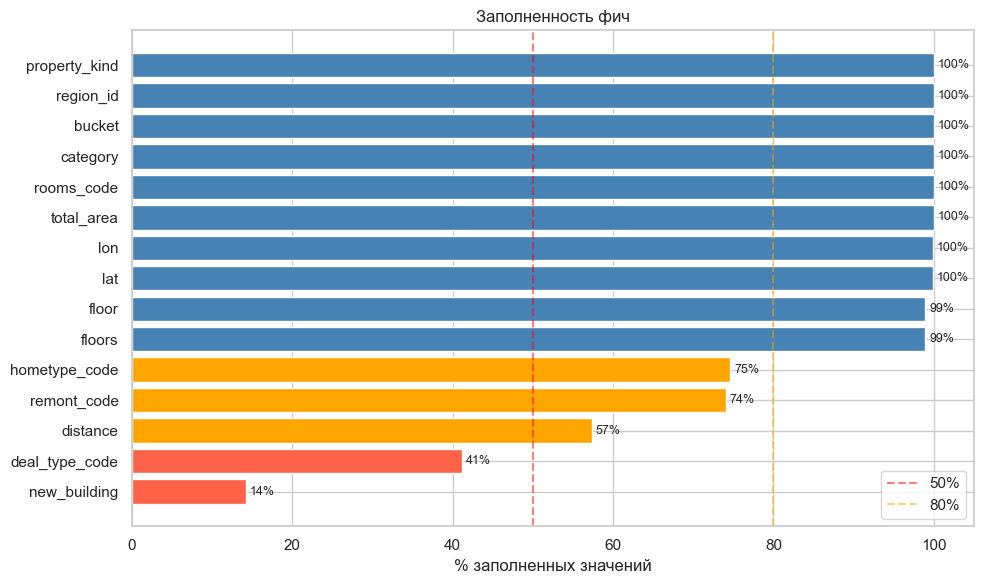

In [12]:
# --- Заполненность фич ---
feature_cols = [
    'total_area', 'rooms_code', 'floor', 'floors', 'distance',
    'remont_code', 'hometype_code', 'deal_type_code', 'category',
    'property_kind', 'region_id', 'bucket', 'new_building', 'lat', 'lon'
]

fill_pct = (df[feature_cols].notna().sum() / len(df) * 100).sort_values()

colors = ['tomato' if v < 50 else 'orange' if v < 80 else 'steelblue' for v in fill_pct]
plt.figure(figsize=(10, 6))
bars = plt.barh(fill_pct.index, fill_pct.values, color=colors)
plt.axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
plt.axvline(80, color='orange', linestyle='--', alpha=0.5, label='80%')
for bar, val in zip(bars, fill_pct.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}%', va='center', fontsize=9)
plt.xlabel('% заполненных значений')
plt.title('Заполненность фич')
plt.legend()
plt.tight_layout()
plt.show()

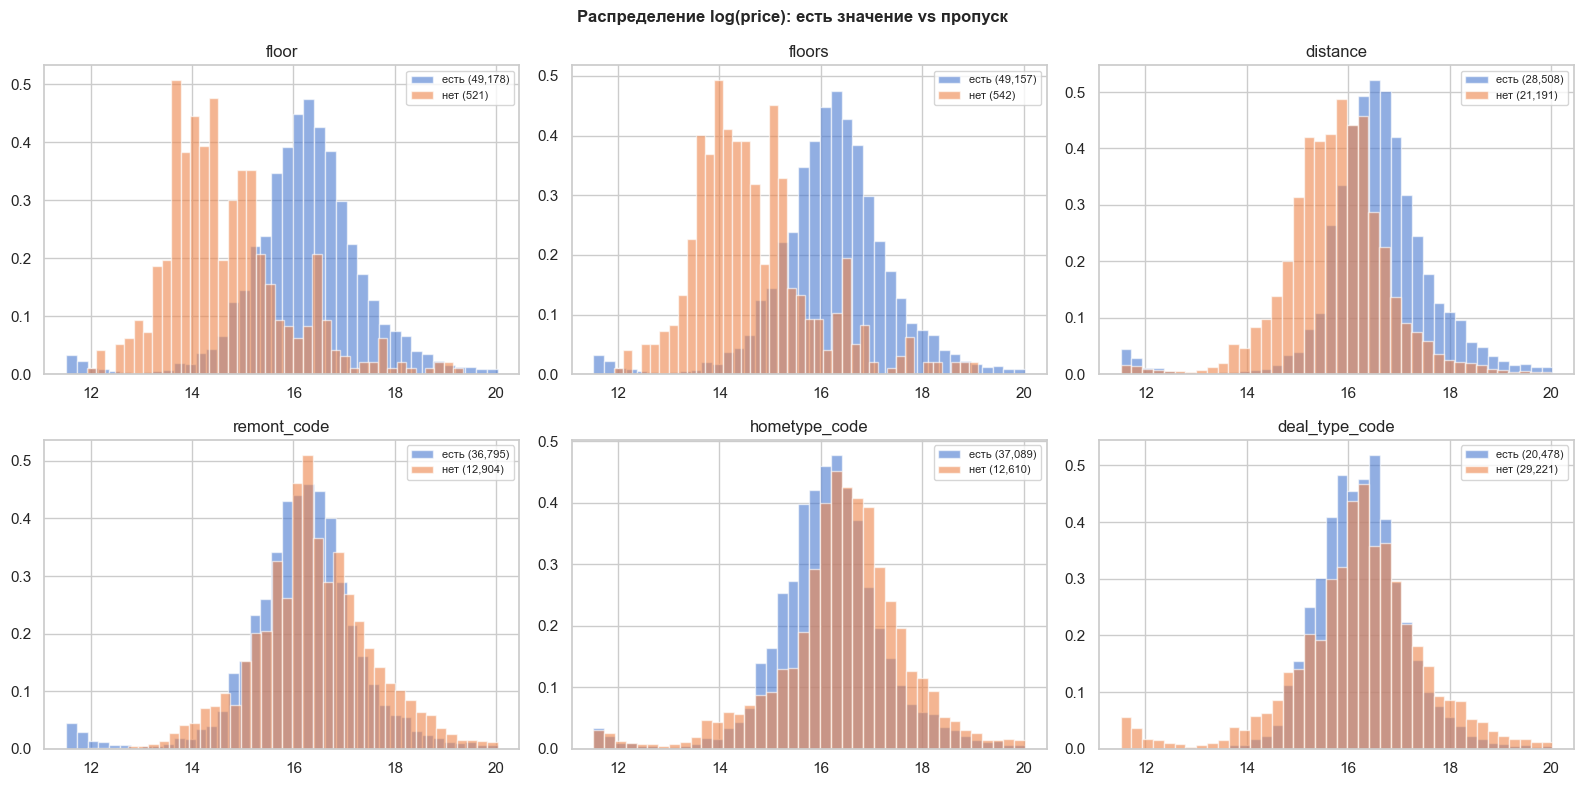

In [13]:
# --- Влияние пропусков на цену ---
cols_with_nulls = [c for c in feature_cols if df[c].isna().any()]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cols_with_nulls[:6]):
    has = df[df[col].notna()]['log_price'].dropna()
    no = df[df[col].isna()]['log_price'].dropna()
    ax.hist(has, bins=40, alpha=0.6, label=f'есть ({len(has):,})', density=True)
    ax.hist(no, bins=40, alpha=0.6, label=f'нет ({len(no):,})', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Распределение log(price): есть значение vs пропуск', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Engineering — производные признаки

In [14]:
# --- Производные фичи ---
df['floor_ratio'] = df['floor'] / df['floors']
df['is_first_floor'] = (df['floor'] == 1).astype('Int8')
df['is_top_floor'] = (df['floor'] == df['floors']).astype('Int8')
df['price_per_m2'] = df['price'] / df['total_area']

new_feats = ['floor_ratio', 'is_first_floor', 'is_top_floor', 'price_per_m2']
corr_new = df[new_feats + ['log_price']].corr()['log_price'].drop('log_price')

print('Корреляция производных фич с log(price):')
print(corr_new.sort_values().to_string())

Корреляция производных фич с log(price):
is_top_floor     -0.236444
is_first_floor   -0.205394
floor_ratio      -0.158414
price_per_m2      0.337286


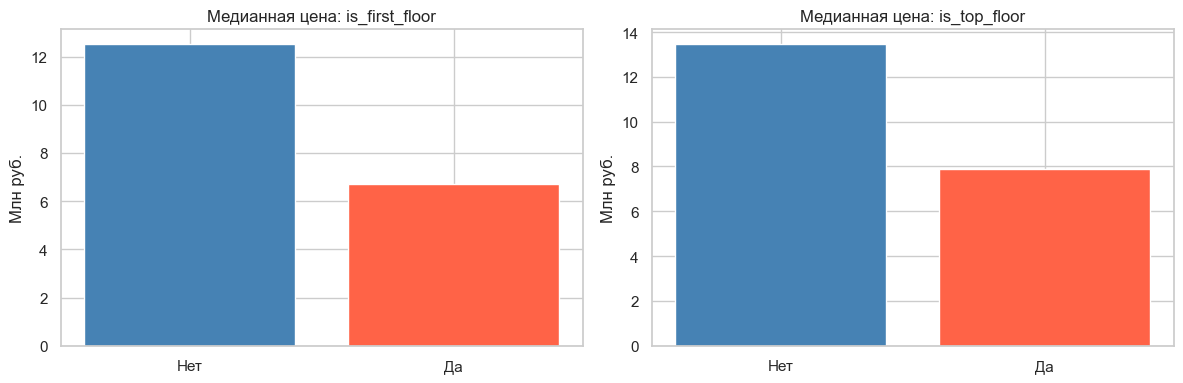

In [15]:
# --- Влияние первого и последнего этажа на цену ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['is_first_floor', 'is_top_floor']):
    groups = df.groupby(col)['price'].median() / 1e6
    groups.index = ['Нет', 'Да']
    ax.bar(groups.index, groups.values, color=['steelblue', 'tomato'])
    ax.set_title(f'Медианная цена: {col}')
    ax.set_ylabel('Млн руб.')

plt.tight_layout()
plt.show()

## 7. Итоговые выводы

In [16]:
print('=' * 60)
print('ИТОГИ EDA')
print('=' * 60)

print(f"""
Датасет:
  Строк:    {len(df):,}
  Колонок:  {df.shape[1]}

Целевая переменная (price):
  Медиана:  {df['price'].median()/1e6:.1f} млн руб.
  Распределение сильно скошено → обучаем на log(price)

Сильные фичи (корреляция с log_price > 0.2):
  total_area, lat, lon, rooms_code

Фичи под вопросом:
  deal_type_code  — заполнен на 26%, но несёт информацию → оставляем (CatBoost справится)
  new_building    — заполнен на 12% → оставляем как есть
  distance        — заполнен на 57% → оставляем

Производные фичи для модели:
  floor_ratio     = floor / floors
  is_first_floor  = floor == 1
  is_top_floor    = floor == floors

Финальный список фич для обучения:
  Числовые:       total_area, floor, floors, distance, lat, lon, floor_ratio
  Категориальные: rooms_code, remont_code, hometype_code, deal_type_code,
                  category, property_kind, region_id, bucket
  Бинарные:       new_building, is_first_floor, is_top_floor
""")

ИТОГИ EDA

Датасет:
  Строк:    49,699
  Колонок:  24

Целевая переменная (price):
  Медиана:  11.5 млн руб.
  Распределение сильно скошено → обучаем на log(price)

Сильные фичи (корреляция с log_price > 0.2):
  total_area, lat, lon, rooms_code

Фичи под вопросом:
  deal_type_code  — заполнен на 26%, но несёт информацию → оставляем (CatBoost справится)
  new_building    — заполнен на 12% → оставляем как есть
  distance        — заполнен на 57% → оставляем

Производные фичи для модели:
  floor_ratio     = floor / floors
  is_first_floor  = floor == 1
  is_top_floor    = floor == floors

Финальный список фич для обучения:
  Числовые:       total_area, floor, floors, distance, lat, lon, floor_ratio
  Категориальные: rooms_code, remont_code, hometype_code, deal_type_code,
                  category, property_kind, region_id, bucket
  Бинарные:       new_building, is_first_floor, is_top_floor

